In [1]:
# Установка библиотек
!pip install flaml scikit-learn pandas matplotlib seaborn

# Импорт и загрузка данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from flaml import AutoML
import warnings
warnings.filterwarnings('ignore')

# URL датасета
url = "https://raw.githubusercontent.com/AI-is-out-there/data2lab/refs/heads/main/%D0%BC%D0%BE%D0%B4%D1%83%D0%BB%D1%8C%203%20-%20%D0%B4%D0%B0%D1%82%D0%B0%D1%81%D0%B5%D1%82%20-%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.csv"

# Загрузка первых 5000 строк
df = pd.read_csv(url, nrows=5000)
print("Исходная форма данных:", df.shape)
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 3.3 MB/s eta 0:00:00
Исходная форма данных: (5000, 36)


,subject_id,Count_subj,study_id,cart_id,Healthy_Status,eeg_time,eeg_date,report_0,report_1,report_2,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,19557662,27,40000017,6848296,0,8:44 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,18477137,93,40000029,6848296,0,9:54 AM,27.06.2015,Sinus rhythm,Possible right atrial abnormality,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,16598616,3,40000035,6376932,1,9:07 AM,28.06.2015,Sinus tachycardia,NaN,Normal ECG except for rate,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,16368287,7,40000079,6214760,1,5:14 PM,15.07.2015,Sinus rhythm,NaN,Normal ECG,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,18370366,2,40000084,6632385,0,1:52 PM,27.09.2015,Sinus rhythm,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77


In [2]:
# Подготовка данных
features = ['Count_subj', 'rr_interval', 'p_end', 'qrs_onset', 'qrs_end', 'p_axis', 'qrs_axis', 't_axis']
target = 'Healthy_Status'

df_model = df[features + [target]].copy()

# Очистка данных
for col in features:
    df_model[col] = df_model[col].replace(29999, np.nan)

# Проверка пропуски
print("Пропуски до заполнения:")
print(df_model.isnull().sum())

# Заполнение пропуски медианой
for col in features:
    median_val = df_model[col].median()
    df_model[col].fillna(median_val, inplace=True)

print("\nДанные после очистки. Размер:", df_model.shape)
print("Распределение целевой переменной (0 - болен, 1 - здоров):")
print(df_model[target].value_counts())

# Разделение на train/test
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Пропуски до заполнения:
Count_subj           0
rr_interval         10
p_end             1542
qrs_onset            9
qrs_end             10
p_axis             842
qrs_axis            27
t_axis              27
Healthy_Status       0
dtype: int64

Данные после очистки. Размер: (5000, 9)
Распределение целевой переменной (0 - болен, 1 - здоров):
Healthy_Status
0    4040
1     960
Name: count, dtype: int64

Размер обучающей выборки: (3500, 8)
Размер тестовой выборки: (1500, 8)


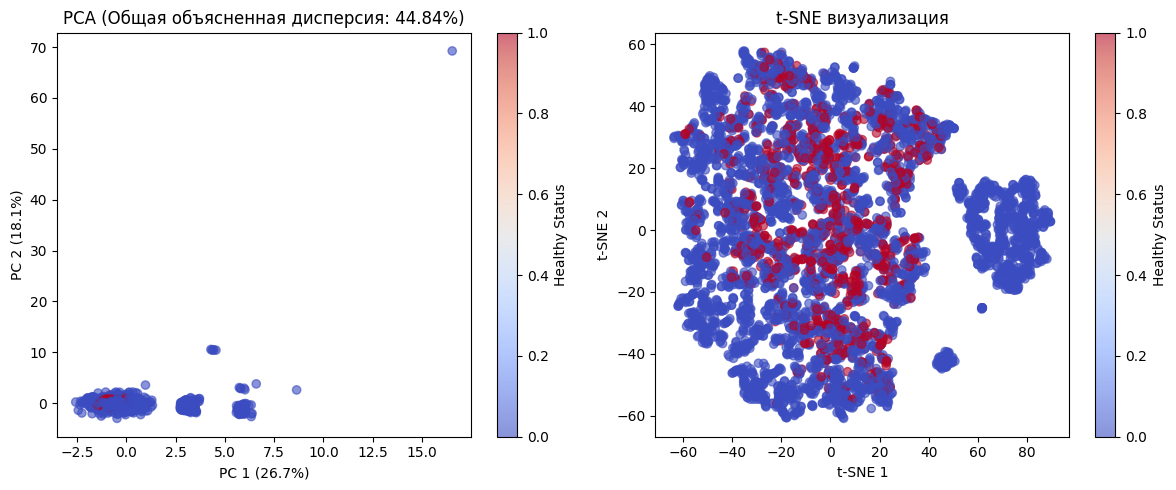

In [3]:
# Визуализация PCA и t-SNE
X_vis = df_model[features]
y_vis = df_model[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_vis, cmap='coolwarm', alpha=0.6)
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'PCA (Общая объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%})')
plt.colorbar(scatter, label='Healthy Status')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_vis, cmap='coolwarm', alpha=0.6)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE визуализация')
plt.colorbar(scatter, label='Healthy Status')
plt.tight_layout()
plt.show()

In [4]:
# AutoML с FLAML
automl = AutoML()

# Настройки AutoML
settings = {
    "time_budget": 60,  # 60 секунд на поиск
    "metric": 'f1',     # Оптимизируем F1-score
    "task": 'classification',
    "log_file_name": 'automl.log',
    "seed": 42,
    "eval_method": 'cv',
    "n_splits": 5,
}

# Обучение AutoML
automl.fit(X_train=X_train, y_train=y_train, **settings)

print("\nЛучшая модель найдена AutoML:")
print(automl.model)
print(f"\nЛучшие параметры: {automl.best_config}")

[flaml.automl.logger: 04-22 13:58:35] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 13:58:35] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 13:58:35] {2489} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 04-22 13:58:35] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3046} INFO - Estimated sufficient time budget=1018s. Estimated necessary time budget=24s.
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.1s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.log

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.4s,	estimator sgd's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.4s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.5s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.6s,	estimator lgbm's best error=1.0000e+00,	best estimator lgbm's best error=1.0000e+00
[flaml.automl.logger: 04-22 13:58:35] {2911} INFO - iteration 8, current learner lgbm
[flaml.automl.logger: 04-22 13:58:35] {3097} INFO -  at 0.6s,	estimator l

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 04-22 13:59:35] {3097} INFO -  at 60.3s,	estimator lrl1's best error=1.0000e+00,	best estimator xgboost's best error=3.6983e-01
[flaml.automl.logger: 04-22 13:59:35] {3359} INFO - retrain xgboost for 0.0s
[flaml.automl.logger: 04-22 13:59:35] {3362} INFO - retrained model: XGBClassifier(base_score=None, booster=None, callbacks=[],
              colsample_bylevel=1.0, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy='lossguide',
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.11554564349411135), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=16,
              min_child_weight=np.float64(0.29453553280651146), missing=nan,
              


F1-мера на тестовой выборке: 0.6288

Classification Report:
              precision    recall  f1-score   support

   Болен (0)       0.92      0.90      0.91      1212
  Здоров (1)       0.61      0.65      0.63       288

    accuracy                           0.85      1500
   macro avg       0.76      0.78      0.77      1500
weighted avg       0.86      0.85      0.85      1500



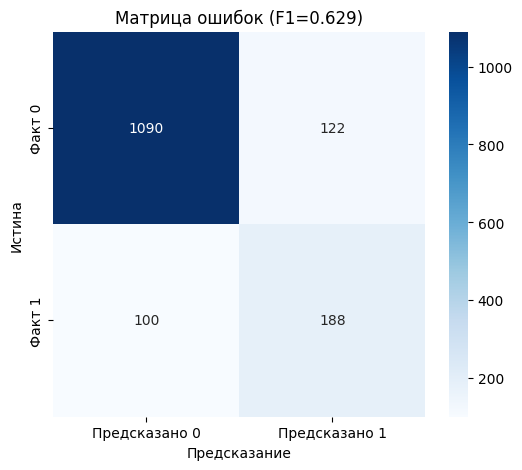

In [5]:
# Оценка лучшей модели
# Предсказания на тесте
y_pred = automl.predict(X_test)

# Метрики
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\n{'='*50}")
print(f"F1-мера на тестовой выборке: {f1:.4f}")
print(f"{'='*50}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Болен (0)', 'Здоров (1)']))

# Визуализация матрицы ошибок
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Факт 0', 'Факт 1'])
plt.title(f'Матрица ошибок (F1={f1:.3f})')
plt.ylabel('Истина')
plt.xlabel('Предсказание')
plt.show()

Сравнение F1-score различных моделей (кросс-валидация):
--------------------------------------------------
Logistic Regression : 0.1622 (+/- 0.0542)
Random Forest       : 0.5959 (+/- 0.0212)
Gradient Boosting   : 0.5914 (+/- 0.0342)
SVM                 : 0.0000 (+/- 0.0000)
KNN                 : 0.4844 (+/- 0.0317)


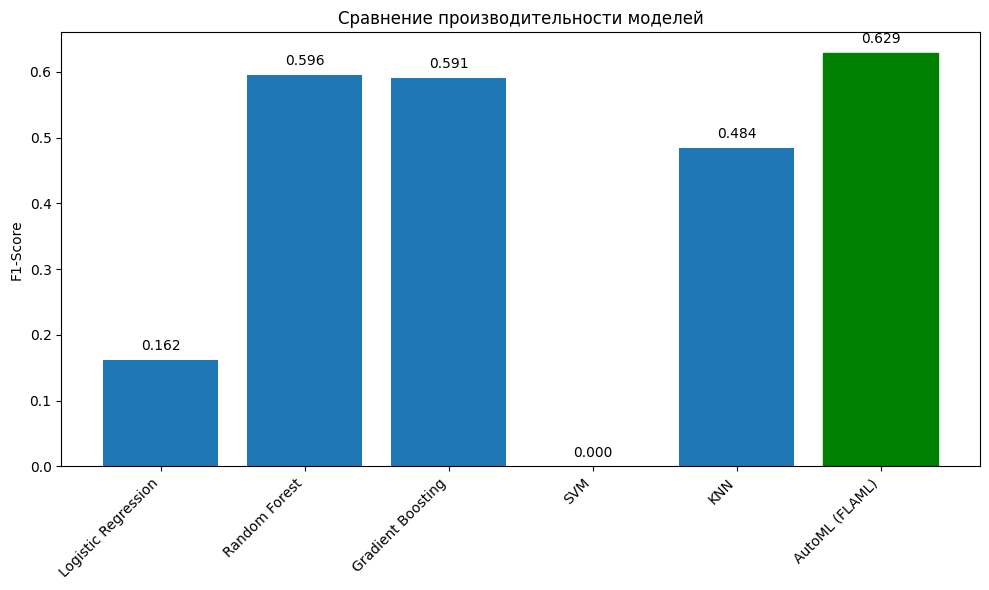


Лучшая модель: AutoML (FLAML) с F1 = 0.6288


In [6]:
# Сравнение с другими моделями
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

print("Сравнение F1-score различных моделей (кросс-валидация):")
print("-" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    results[name] = scores.mean()
    print(f"{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

results['AutoML (FLAML)'] = f1

# Визуализация сравнения
plt.figure(figsize=(10,6))
bars = plt.bar(results.keys(), results.values())
plt.ylabel('F1-Score')
plt.title('Сравнение производительности моделей')
plt.xticks(rotation=45, ha='right')

# Лучшая модель
best_model_name = max(results, key=results.get)
bars[list(results.keys()).index(best_model_name)].set_color('green')

# Значения на столбцы
for bar, value in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nЛучшая модель: {best_model_name} с F1 = {results[best_model_name]:.4f}")

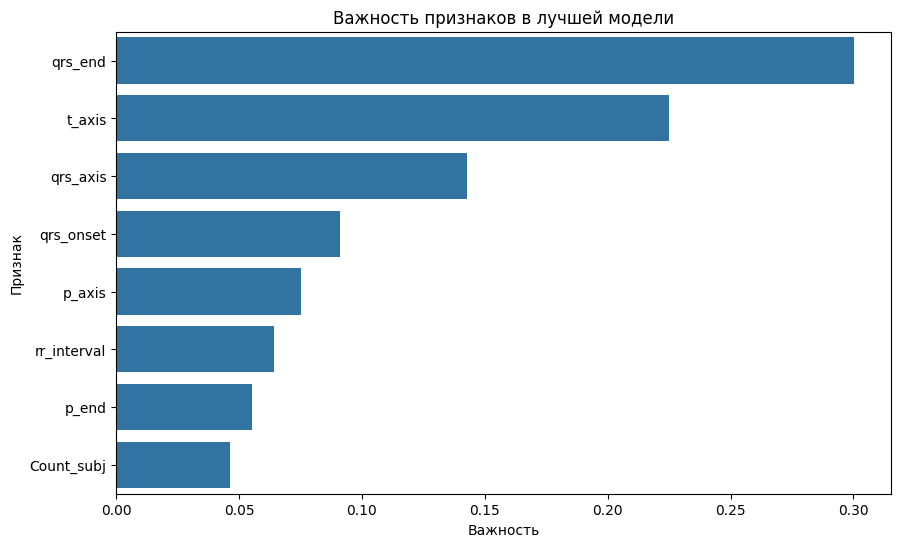

Топ признаков по важности:
       Признак  Важность
4      qrs_end  0.300411
7       t_axis  0.224951
6     qrs_axis  0.142820
3    qrs_onset  0.090938
5       p_axis  0.075010
1  rr_interval  0.064219
2        p_end  0.055415
0   Count_subj  0.046236


In [7]:
# Важность признаков
if hasattr(automl.model, 'feature_importances_'):
    importances = automl.model.feature_importances_
    feature_importance = pd.DataFrame({
        'Признак': features,
        'Важность': importances
    }).sort_values('Важность', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feature_importance, x='Важность', y='Признак')
    plt.title('Важность признаков в лучшей модели')
    plt.show()

    print("Топ признаков по важности:")
    print(feature_importance)
elif hasattr(automl.model, 'coef_'):
    importances = np.abs(automl.model.coef_[0])
    feature_importance = pd.DataFrame({
        'Признак': features,
        'Важность': importances
    }).sort_values('Важность', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feature_importance, x='Важность', y='Признак')
    plt.title('Абсолютные коэффициенты модели')
    plt.show()